Name

Labpartner(s)

In [1]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

**For today's lab you need to install the package cartopy**

In [2]:
# you can install packages here in a notebook with pip or conda, 
# or in the anaconda navigator in the environments tab (reccommended)
# pip install cartopy
# conda install cartopy

In [3]:
# I had an old version of cartopy so I had to upgrade:
# pip install --upgrade cartopy

In [2]:
import cartopy.crs as ccrs   #import map styles/types

In [3]:
import cartopy.feature as cfeature  # features such as the ocean, coastlines rivers, etc

# Class 6.2

Today we will finish fiunction sharing and do more plotting

# Warmups 6.2

**W.1** Write some code that generates 15 random integers from 1-100. If the integers are divisible by 2 assign them to list "x" if they are divisible by three, assign them to list "y", if they are neither assign them to list "z". 

In [6]:
num = np.random.randint(1,101,15)


In [7]:
num

array([88, 83, 33, 35, 13, 15, 33, 85, 28, 62, 43, 44, 82, 90, 12])

In [8]:
x = num[num % 2 == 0]                                
y = num[num % 3 == 0]                                
z = num[(num % 2 != 0) & (num % 3 != 0)]  

print('Generated numbers:', num)
print('Divisible by 2:', x)
print('Divisible by 3:', y)
print('Neither:', z)

Generated numbers: [88 83 33 35 13 15 33 85 28 62 43 44 82 90 12]
Divisible by 2: [88 28 62 44 82 90 12]
Divisible by 3: [33 15 33 90 12]
Neither: [83 35 13 85 43]


# Lecture 6.2

### Agenda:

- Show us your functions
- Questions
- Cartopy!

### Show us your functions (from Lab 5.2) - continued

### Questions

### Cartopy

Let's take the data we used last time and make the plot publication ready

There are a number of differnt map projections available in Cartopy.  
https://cartopy.readthedocs.io/stable/reference/projections.html
Robinson is often used for global maps

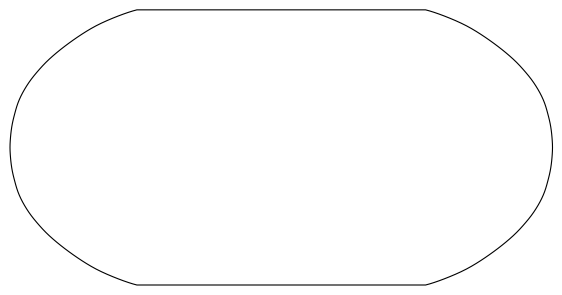

In [9]:
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())

C:\ProgramData\anaconda3\envs\JGERAL7\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


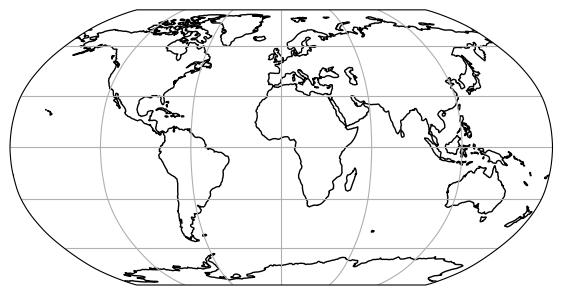

In [10]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(resolution='110m')
ax.gridlines()

When we are plotting ocean data, we like to make the Pacific contiguous, let's rotate

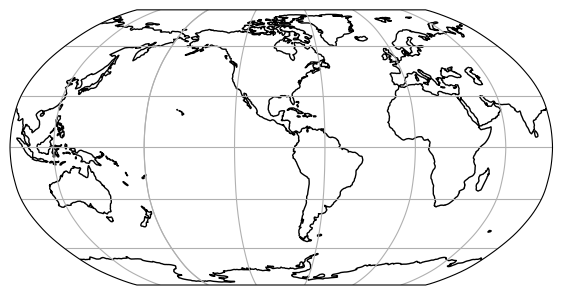

In [11]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 360-89)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

Or we can rotate it so that it cuts through Indonesia (not good for mangrove or coral work)

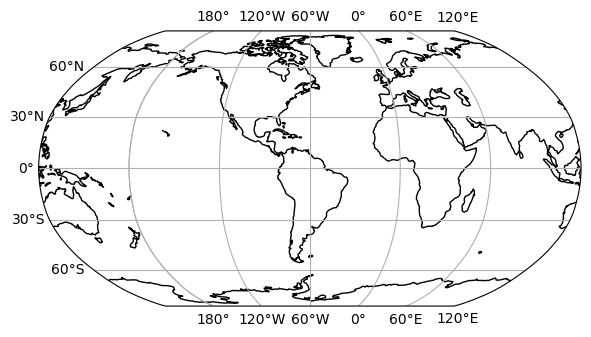

In [12]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = -60))
# -60 (60 W) is the same as 300 E (360 degrees in total 360-60W = 300E)
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True) # let's add some labels


Let's try some different map projections

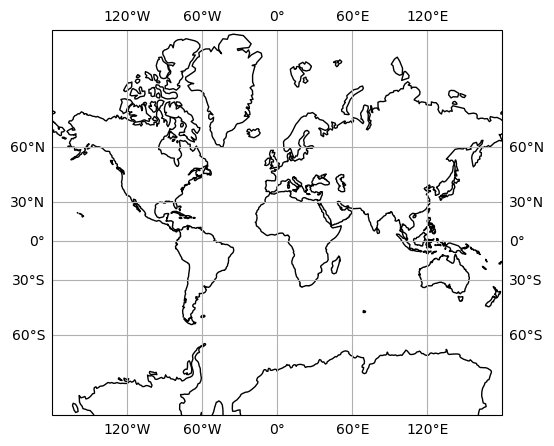

In [13]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Mercator()) # different map projection
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

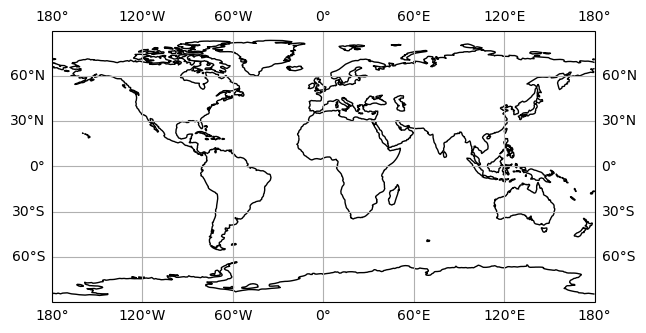

In [14]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)


How do I zoom in?

C:\ProgramData\anaconda3\envs\JGERAL7\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


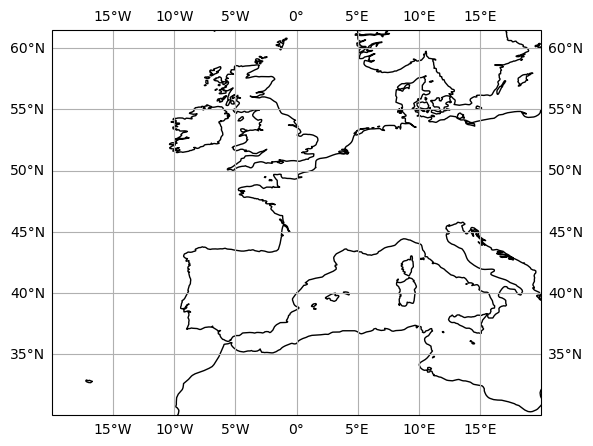

In [15]:
# let's zoom in to S Asia
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20, 20, 30, 60 ]) # set the limits of the plot [lon_min, lon_max, lat_min, lat_max]
ax.coastlines(resolution='50m') # zoom in then need more resolution
ax.gridlines(draw_labels=True)


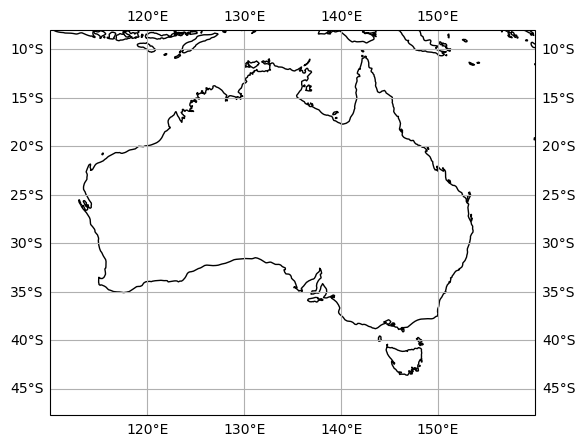

In [16]:
# make a plot of Australia

plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 160, -8, -45]) # set the limits of the plot
ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)



#### Moving back to the Gulf of Mexico, we want to set the lat and lon range to match our HYCOM data. How do we find this?

In [17]:
#insert path or url to file here
# download from the internet:
link = "https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc"

In [18]:
gom_data = xr.open_dataset(link, decode_times=False)

In [19]:
gom_data.Date

<xarray.DataArray 'Date' (MT: 1)>
[1 values with dtype=float64]
Coordinates:
  * MT       (MT) float64 4.566e+04
    Date     (MT) float64 ...
Attributes:
    units:           day as %Y%m%d.%f
    C_format:        %13.4f
    FORTRAN_format:  (f13.4)
    long_name:       date
    _ChunkSizes:     512

In [20]:
gom_data.MT

<xarray.DataArray 'MT' (MT: 1)>
array([45657.])
Coordinates:
  * MT       (MT) float64 4.566e+04
    Date     (MT) float64 ...
Attributes:
    long_name:    time
    units:        days since 1900-12-31 00:00:00
    calendar:     gregorian
    axis:         T
    _ChunkSizes:  512

In [21]:
gom_data

<xarray.Dataset>
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 4.566e+04
    Date                   (MT) float64 ...
  * Latitude               (Latitude) float32 18.09 18.13 18.17 ... 31.93 31.96
  * Longitude              (Longitude) float32 -98.0 -97.96 ... -77.08 -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 ...
    surface_n_stress       (MT, Latitude, Longitude) float32 ...
    ssh                    (MT, Latitude, Longitude) float32 ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

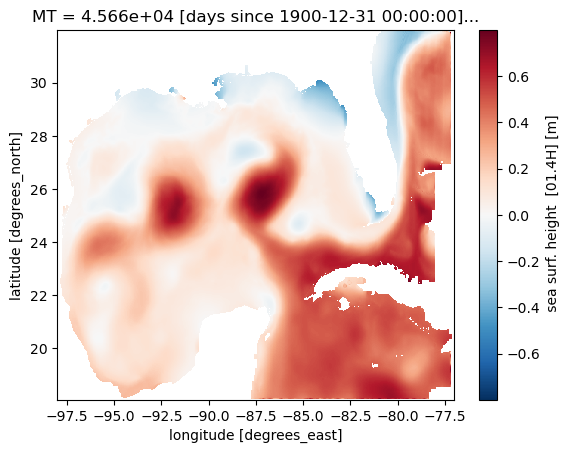

In [22]:
# let's remember what our data looked like, pick a variable to plot

gom_data.ssh.plot()

I'm going to get the max and min of the lat and lon to help me plot the data

In [23]:
lat_min = gom_data.Latitude.min()
print(lat_min)

<xarray.DataArray 'Latitude' ()>
array(18.0916481)


In [24]:
lat_max = gom_data.Latitude.max()
print(lat_max)

<xarray.DataArray 'Latitude' ()>
array(31.96064758)


In [25]:
lon_min = gom_data.Longitude.min()
print(lon_min)

<xarray.DataArray 'Longitude' ()>
array(-98.)


In [26]:
lon_max = gom_data.Longitude.max()
print(lon_max)

<xarray.DataArray 'Longitude' ()>
array(-77.03997803)


Now I can use them below

C:\ProgramData\anaconda3\envs\JGERAL7\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


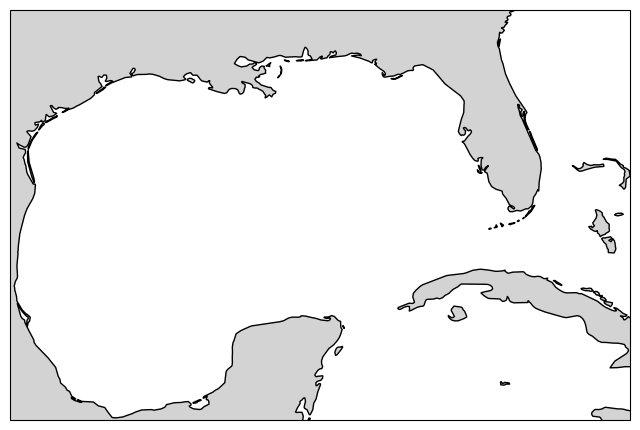

In [27]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='lightgrey')
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Let's make the land color a bit lighter gray

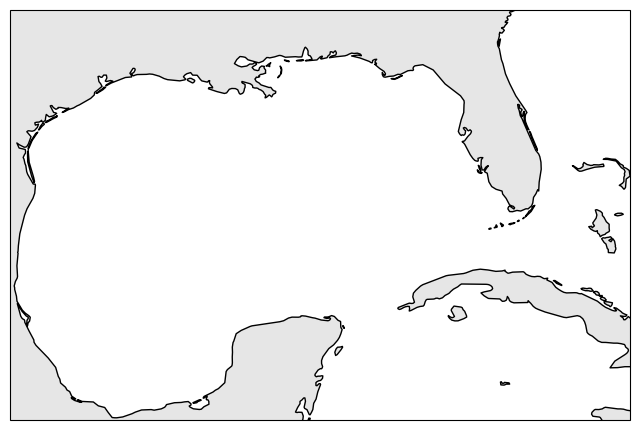

In [28]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9') # 0 is black and 1 is white
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Now let's add some data

In [29]:
# lets figure out what var is

var = gom_data.ssh[0,:,:] # get rid of the time dimension
var

<xarray.DataArray 'ssh' (Latitude: 385, Longitude: 525)>
[202125 values with dtype=float32]
Coordinates:
    MT         float64 4.566e+04
    Date       float64 ...
  * Latitude   (Latitude) float32 18.09 18.13 18.17 18.21 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 -98.0 -97.96 -97.92 ... -77.12 -77.08 -77.04
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]

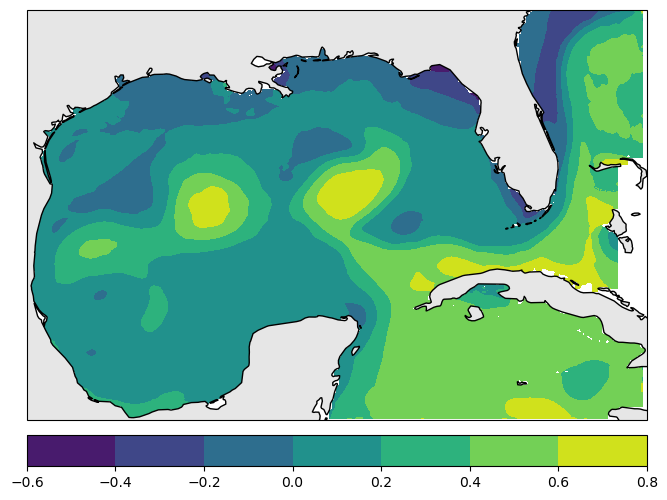

In [30]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)
#cbar = plt.colorbar(p, orientation='horizontal')
#cbar = plt.colorbar(p)


#### Try taking out the options for the colorbar, what happens? What does "pad" do?

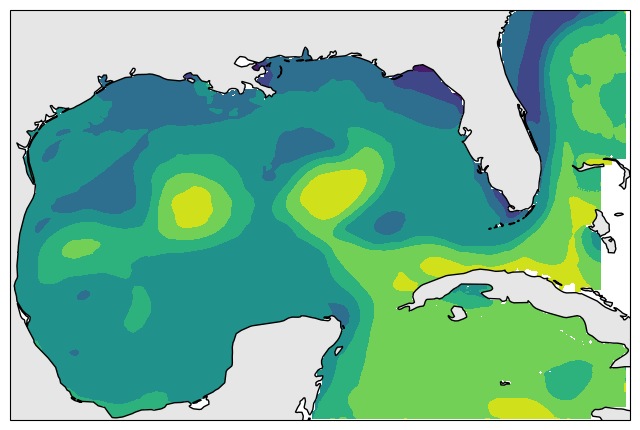

In [31]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
#cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)
#cbar = plt.colorbar(p, orientation='horizontal')
#cbar = plt.colorbar(p)



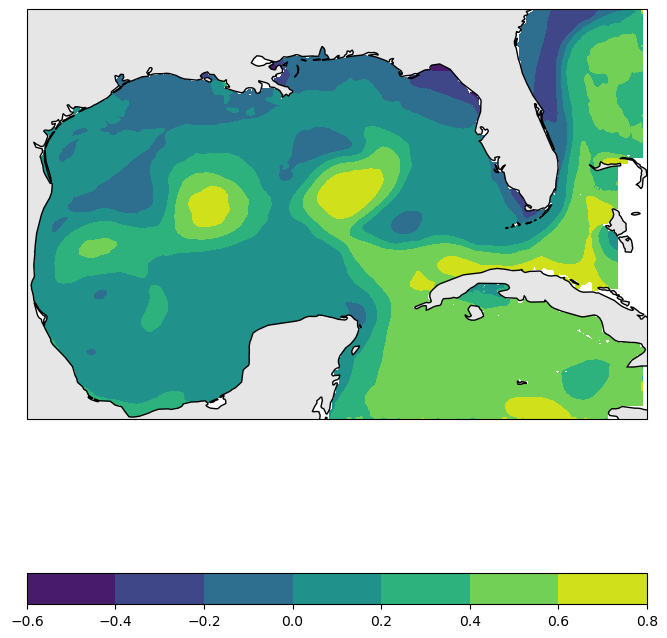

In [32]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# Contours the data on tho the map projection
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.2)
#cbar = plt.colorbar(p, orientation='horizontal')
#cbar = plt.colorbar(p)


increases the distance between the plot and the color bar

#### What is the range of our data?

In [33]:
print(var.max())

<xarray.DataArray 'ssh' ()>
array(0.79863578)
Coordinates:
    MT       float64 4.566e+04
    Date     float64 ...


In [34]:
print(var.min())

<xarray.DataArray 'ssh' ()>
array(-0.504511)
Coordinates:
    MT       float64 4.566e+04
    Date     float64 ...


#### Let's set the countour levels to match our data range. I'm also going to change the colormap
See https://matplotlib.org/stable/users/explain/colors/colormaps.html
Note you can reverse any colormap by appending '_r' to the name

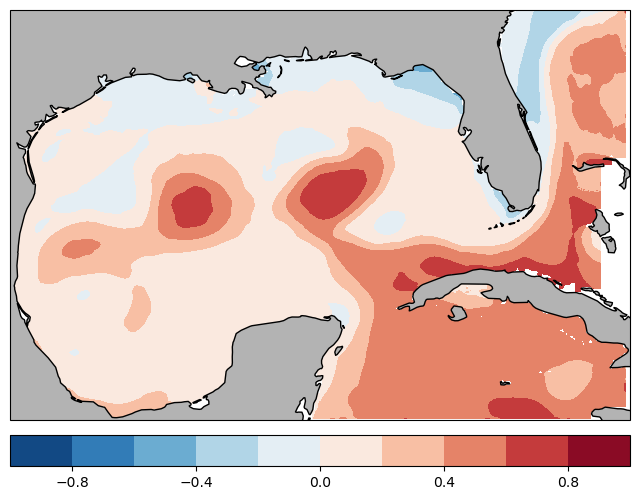

In [35]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.2)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Okay, now let's add some labels

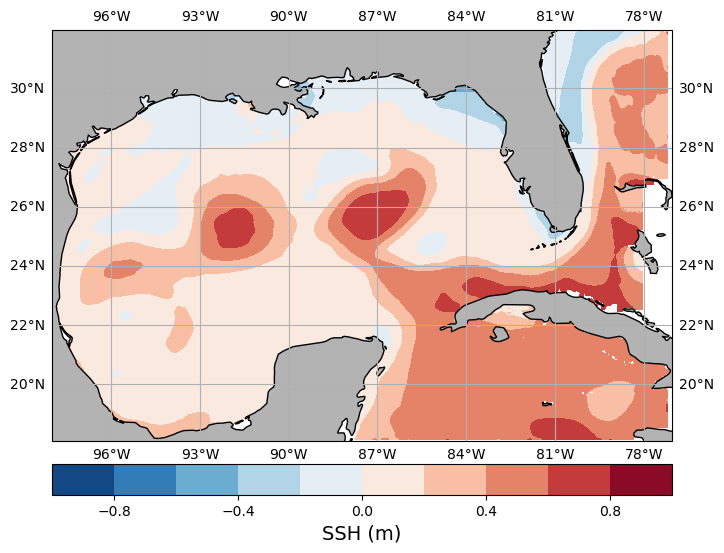

In [36]:
# copy in previous code here
# I'm also going to cut out the white bits at right by adjusting lon_max

fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.2)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.03)

cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)


#### These labels are too small for what I want. I need them to be much bigger.

In [37]:
#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl
mpl.rcParams['font.size'] = 14

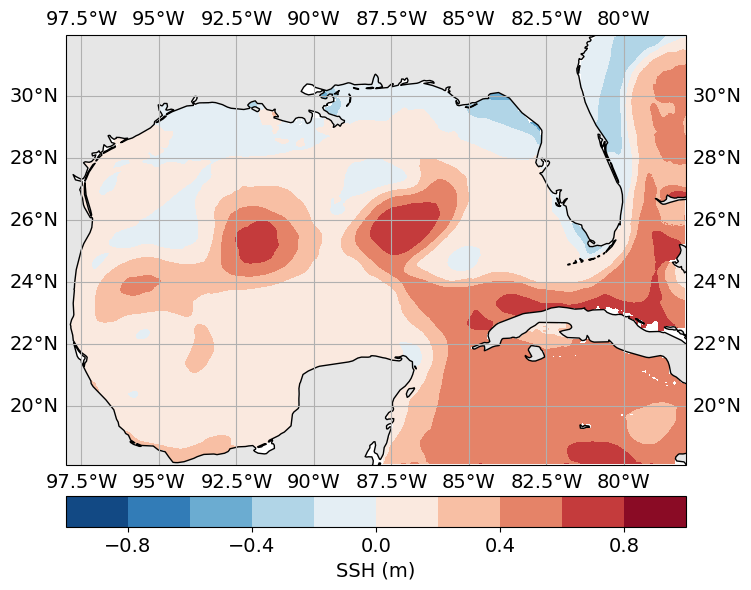

In [38]:
#exact same code as before
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, -78, lat_min, lat_max]) # note I also modified the lon_max here to cut off the white bit.

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.2)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'RdBu_r', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.04)
cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

#### Not bad

## Lab 6.2

**E.0** Finish Lab 6.1 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 3-4. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

**E.3** Make a plot of a different variable for the HYCOM data. Play around with colormaps and contourlines to make it your own. Post your plot on the class slack #programming channel

In [62]:
import xarray as xr

src = "https://tds.hycom.org/thredds/dodsC/GOMu0.04/expt_50.1/data/netcdf/2005"
ds = xr.open_dataset(src, engine="netcdf4", decode_times=False)
ds


<xarray.Dataset>
Dimensions:     (depth: 40, lat: 346, lon: 541, time: 2920)
Coordinates:
  * depth       (depth) float64 0.0 2.0 4.0 6.0 ... 2.5e+03 3e+03 4e+03 5e+03
  * lat         (lat) float64 18.12 18.16 18.2 18.24 ... 31.8 31.84 31.88 31.92
  * lon         (lon) float64 -98.0 -97.96 -97.92 -97.88 ... -76.48 -76.44 -76.4
  * time        (time) float64 4.385e+04 4.385e+04 ... 5.26e+04 5.26e+04
Data variables:
    tau         (time) float64 ...
    water_u     (time, depth, lat, lon) float32 ...
    water_v     (time, depth, lat, lon) float32 ...
    water_temp  (time, depth, lat, lon) float32 ...
    salinity    (time, depth, lat, lon) float32 ...
    surf_el     (time, lat, lon) float32 ...
Attributes:
    classification_level:      UNCLASSIFIED
    distribution_statement:    Approved for public release. Distribution unli...
    downgrade_date:            not applicable
    classification_authority:  not applicable
    institution:               Naval Oceanographic Office
    source:                    HYCOM archive file
    history:                   archv2ncdf3z
    field_type:                instantaneous
    Conventions:               CF-1.6 NAVO_netcdf_v1.1

In [63]:
# index time step (index 0) and depth
wt_slice = ds.water_temp.isel(time=0, depth=20)

print("Valid grid cells:", wt_slice.count().item())
print("Minimum water temp:", wt_slice.min().item())
print("Maximum water temp:", wt_slice.max().item())

Valid grid cells: 98074
Minimum water temp: 13.527999877929688
Maximum water temp: 28.993000030517578


In [64]:
# time and depth
wt_20m = ds.water_temp.sel(depth=20, method="nearest").isel(time=0)

# Mask out land values
wt_20m = wt_20m.where(wt_20m < 1e10)

wt_20m

<xarray.DataArray 'water_temp' (lat: 346, lon: 541)>
array([[   nan,    nan,    nan, ...,    nan,    nan,    nan],
       [   nan,    nan,    nan, ...,    nan,    nan,    nan],
       [   nan,    nan,    nan, ...,    nan,    nan,    nan],
       ...,
       [   nan,    nan,    nan, ..., 22.591, 22.581,    nan],
       [   nan,    nan,    nan, ..., 22.671, 22.617,    nan],
       [   nan,    nan,    nan, ..., 22.724, 22.656,    nan]],
      dtype=float32)
Coordinates:
    depth    float64 20.0
  * lat      (lat) float64 18.12 18.16 18.2 18.24 ... 31.8 31.84 31.88 31.92
  * lon      (lon) float64 -98.0 -97.96 -97.92 -97.88 ... -76.48 -76.44 -76.4
    time     float64 4.385e+04
Attributes:
    long_name:      Water Temperature
    standard_name:  sea_water_temperature
    units:          degC
    NAVO_code:      15
    comment:        in-situ temperature

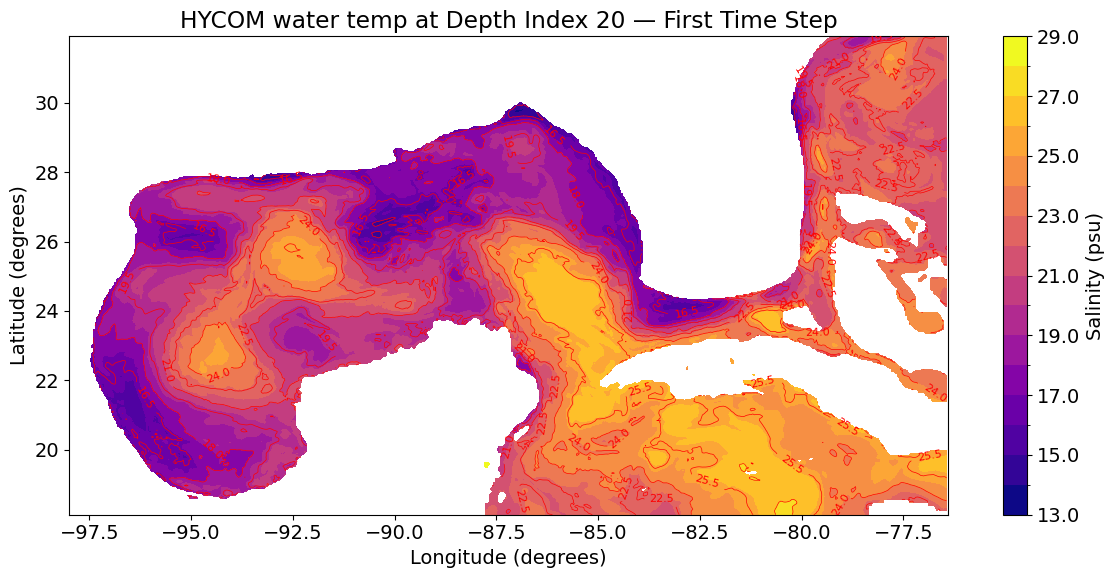

In [65]:
#1. Slice the 4D data down to 2D first!
# Select the first time step (index 0) and the 20th depth layer (index 20)
wt_2d = ds.water_temp.isel(time=0, depth=20)

# Mask out the land values 
wt_2d = wt_2d.where(wt_2d < 1e10)

# 2. Now create the figure and plot the 2D slice
fig, ax = plt.subplots(figsize=(12, 6))

wt_2d.plot.contourf(ax=ax, x="lon", y="lat", levels=20, cmap="plasma", 
                          cbar_kwargs={"label": "Salinity (psu)", "format": "%.1f"})

lines = wt_2d.plot.contour(ax=ax, x="lon", y="lat", levels=15, colors="red", linewidths=0.5)

ax.clabel(lines, fontsize=8, fmt="%.1f")
ax.set_title("HYCOM water temp at Depth Index 20 — First Time Step")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")

plt.tight_layout()
plt.show()

Valid grid cells: 98074
Minimum water temp: 13.527999877929688
Maximum water temp: 28.993000030517578


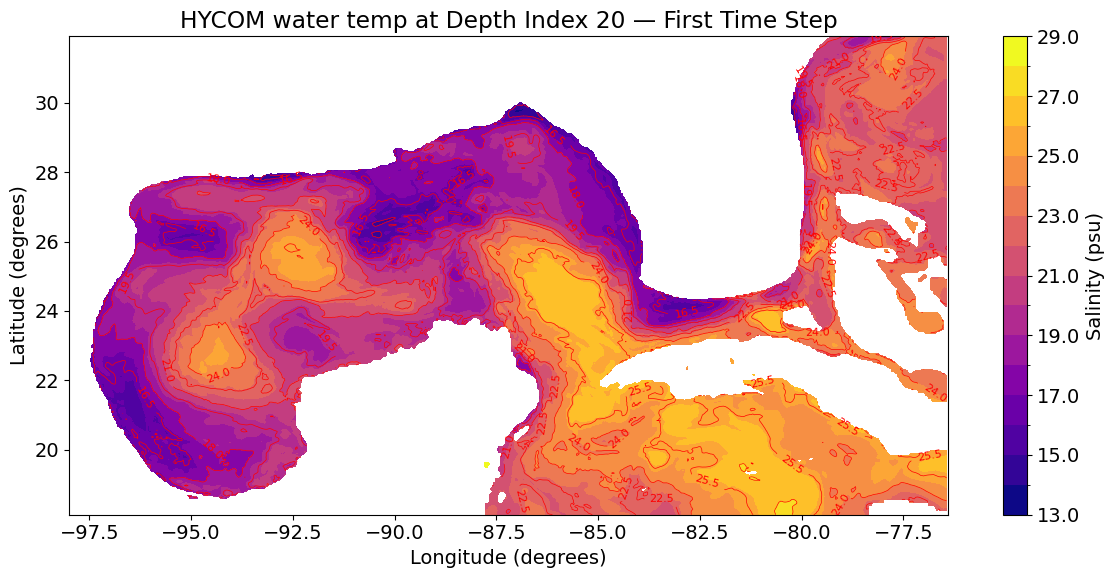

In [67]:

src = "https://tds.hycom.org/thredds/dodsC/GOMu0.04/expt_50.1/data/netcdf/2005"
ds = xr.open_dataset(src, engine="netcdf4", decode_times=False)

ds

wt_slice = ds.water_temp.isel(time=0, depth=20)

print("Valid grid cells:", wt_slice.count().item())
print("Minimum water temp:", wt_slice.min().item())
print("Maximum water temp:", wt_slice.max().item())

# time and depth
wt_20m = ds.water_temp.sel(depth=20, method="nearest").isel(time=0)

# Mask out land values
wt_20m = wt_20m.where(wt_20m < 1e10)

wt_20m

# Select the first time step (index 0) and the 20th depth layer (index 20)
wt_2d = ds.water_temp.isel(time=0, depth=20)

# Mask out the land values 
wt_2d = wt_2d.where(wt_2d < 1e10)

# 2. Now create the figure and plot the 2D slice
fig, ax = plt.subplots(figsize=(12, 6))

wt_2d.plot.contourf(ax=ax, x="lon", y="lat", levels=20, cmap="plasma", 
                          cbar_kwargs={"label": "Salinity (psu)", "format": "%.1f"})

lines = wt_2d.plot.contour(ax=ax, x="lon", y="lat", levels=15, colors="red", linewidths=0.5)

ax.clabel(lines, fontsize=8, fmt="%.1f")
ax.set_title("HYCOM water temp at Depth Index 20 — First Time Step")
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")

plt.tight_layout()
plt.show()
fig.savefig(r"C:\Users\Jeremy Gerald\OneDrive\Documents\scientific_computing\wt_20m.png", dpi=300, bbox_inches="tight")

### This week's project:

#### Note you might want to restart your kernel at this point to dump all the hycom data from memory. Just reload the packages you need

**E.4** Download some data from the ISIMIP data archive (https://data.isimip.org/) and plot it using cartopy. ISIMIP provides bias-corrected data for past and future climate simulations used for impacts studies world wide. Let's start with some maximum atmospheric surface temperature data in the historical period (1850-2014 for CMIP6). We want climate forcing data for ISIMIP3b, which are the lastest (CMIP6) climate projections. 

* https://data.isimip.org/search/tree/ISIMIP3b/InputData/climate/
* Click atmopsheric forcing
* Click GFDL... This is one of NOAA-GFDL's climate models (ESM4)
* Click historical

All of the variable names are in CMIP lingo. Sadly, there is no easy cheat sheet. But you want tas, which is "temperature of air at surface". Let's use the tasmax, the maximum daily surface air temperature
* Click tasmax
* Click files to see all the available files.
  
Here you have a choice, you can download an etire file (note the size) or you can use the "configure download" button, which has subsetting by space or country, as well as time opitons. You can click on a file name to see more info.
* Click on "download file" for the 1851-1860 file. Just grab the whole file, it will take a minute to download.
* Load up the data into xarray and plot the maximum of this dataset (so max over the decade for each gridcell. You just use a max function for this, no loops needed).
* Plot using cartopy to make it pretty. Put some sensible lables on it, etc. Maybe add some country boundaries.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import random
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature 

path= r"C:\Users\Jeremy Gerald\OneDrive\Scientific_Computing\gfdl-esm4_r1i1p1f1_w5e5_historical_tasmax_global_daily_1851_1860.nc"
data = xr.open_dataset(path, decode_times=False)
data

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360, time: 3653)
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) float64 0.0 1.0 2.0 3.0 ... 3.65e+03 3.651e+03 3.652e+03
Data variables:
    tasmax   (time, lat, lon) float32 ...
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [2]:
max_1851_1860 = data.max(dim = 'time')
print(max_1851_1860)

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360)
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
Data variables:
    tasmax   (lat, lon) float32 274.9 274.9 274.9 274.9 ... 258.2 258.3 258.3


In [3]:
lat_min = max_1851_1860.lat.min()
lat_max = max_1851_1860.lat.max()
lon_min = max_1851_1860.lon.min()
lon_max = max_1851_1860.lon.max()

C:\ProgramData\anaconda3\envs\JGERAL7\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


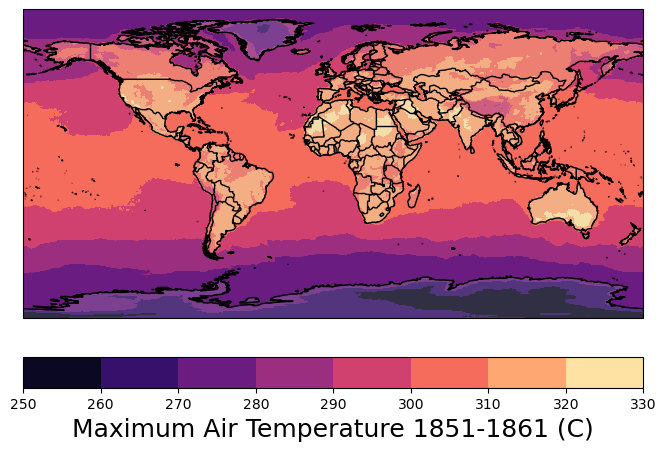

In [6]:
fig,ax= plt.subplots(figsize =(8,10), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.8',
                                       alpha = 0.2)
ax.add_feature(land_50m)

# COAST AND BORDERS 
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=1)
ax.coastlines(resolution='50m', color='black', linewidth=1)

x = max_1851_1860.lon
y = max_1851_1860.lat
var =  max_1851_1860.tasmax
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'magma') 

cbar = plt.colorbar( p, orientation='horizontal', pad=0.05, fraction=0.05)
cbar.set_label("Maximum Air Temperature 1851-1861" +' (C)', size = 18)


**E.5** Now make a second plot using ISIMP data for a future climate projection. Following the same steps as above, get the GFDL tasmax data for the future climate scenario SSP3-7.0 (higher emissions scenario) for 2051-2060. Again, calculate the maximum at each gridpoint for this data set. This is the future maximum daily temperature for that decade. Make your plot nice.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import random
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature 

path= r"C:\Users\Jeremy Gerald\OneDrive\Documents\scientific_computing\gfdl-esm4_r1i1p1f1_w5e5_ssp370_tasmax_global_daily_2051_2060.nc"
data = xr.open_dataset(path, decode_times=False)
data

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360, time: 3653)
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) float64 0.0 1.0 2.0 3.0 ... 3.65e+03 3.651e+03 3.652e+03
Data variables:
    tasmax   (time, lat, lon) float32 ...
Attributes:
    institution:  Potsdam Institute for Climate Impact Research (PIK)
    contact:      ISIMIP cross-sectoral science team <info@isimip.org> <https...
    references:   Lange (2019) <https://doi.org/10.5194/gmd-12-3055-2019> and...
    title:        ISIMIP3b bias-adjusted climate input data
    project:      Inter-Sectoral Impact Model Intercomparison Project phase 3...
    summary:      CMIP6 daily output data bias-adjusted and statistically dow...

In [8]:
max_2051_2060 = data.max(dim = 'time')
print(max_2051_2060)

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360)
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
Data variables:
    tasmax   (lat, lon) float32 275.3 275.3 275.4 275.3 ... 255.0 255.3 255.0


In [9]:
lat_min = max_2051_2060.lat.min()
lat_max = max_2051_2060.lat.max()
lon_min = max_2051_2060.lon.min()
lon_max = max_2051_2060.lon.max()

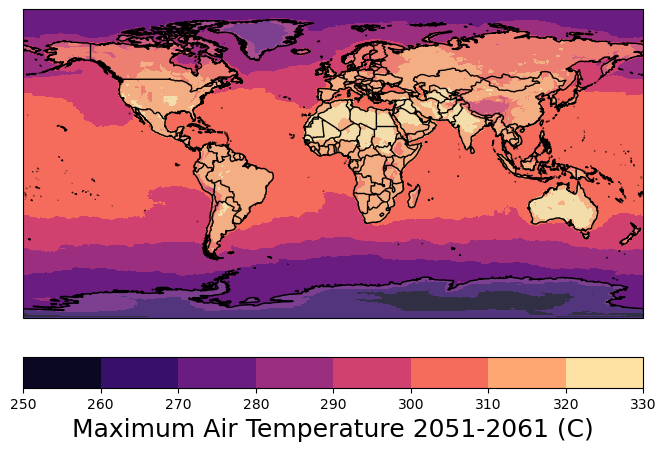

In [10]:
fig,ax= plt.subplots(figsize =(8,10), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.8',
                                       alpha = 0.2)
ax.add_feature(land_50m)

# COAST AND BORDERS 
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=1)
ax.coastlines(resolution='50m', color='black', linewidth=1)

x = max_2051_2060.lon
y = max_2051_2060.lat
var =  max_2051_2060.tasmax
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'magma') 

cbar = plt.colorbar( p, orientation='horizontal', pad=0.05, fraction=0.05)
cbar.set_label("Maximum Air Temperature 2051-2061" +' (C)', size = 18)


**E.6** Now plot the anomaly between the two, 2050's - 1850's. Use a diverging colormap (light in the middle), centered on zero. What is the outlook for your country of orgin? Answer in full sentances with specific numbers.

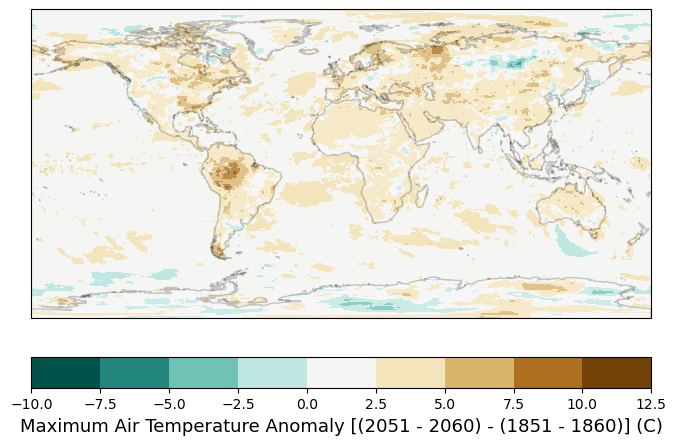

In [12]:
anomaly = max_2051_2060 - max_1851_1860

fig,ax= plt.subplots(figsize =(8,10), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='1',
                                       alpha = 0.2)

ax.add_feature(land_50m)

x = anomaly.lon
y = anomaly.lat
var =  anomaly.tasmax
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'BrBG_r') 

cbar = plt.colorbar( p, orientation='horizontal', pad=0.05, fraction=0.05)
cbar.set_label("Maximum Air Temperature Anomaly [(2051 - 2060) - (1851 - 1860)]" +' (C)', size = 13)

**E.7** How could you potentially use this kind of data (future climate projections) in your research? Do some brainstorming. Write down your thoughts here.

These types of climate projections could be useful in predicting droughts and increased occurence of RI in hurricane systems. both items are part of the major research I am conducting for my dissertation.